In [ ]:
import pandas as pd
import numpy as np

from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import ConfusionMatrixDisplay


In [ ]:
# Load data
neg_data = pd.read_csv('UPD_NEG_DATA.txt', sep='\t', index_col=0, header=0).T
pos_data = pd.read_csv('UPD_POS_DATA.txt', sep='\t', index_col=0, header=0).T

# # Add labels
neg_data['Target'] = 0
pos_data['Target'] = 1

neg_data.dropna(axis=1, inplace=True)
pos_data.dropna(axis=1, inplace=True)

In [ ]:
neg_data = neg_data.reset_index(drop=True)
pos_data = pos_data.reset_index(drop=True)

In [ ]:
pos_data

MB_ID,as_1,as_2,as_3,as_4,as_5,as_6,as_7,as_8,as_9,as_10,...,as_791,as_792,as_793,as_794,as_795,as_796,as_797,as_798,as_799,Target
0,0,5141,544,0,0,0,0,0,662,0,...,0,0,0,0,0,0,0,0,0,1
1,422,0,0,0,696,0,571,147,0,474,...,0,0,0,0,0,0,0,0,0,1
2,1346,0,49,627,0,0,210,206,562,0,...,0,0,0,0,0,0,0,0,0,1
3,405,0,378,0,116,601,0,0,67,0,...,0,0,0,0,0,0,3,0,0,1
4,960,108,256,1158,77,0,166,0,67,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1116,1241,1104,0,777,2505,0,0,1767,736,0,...,0,0,0,0,0,0,0,0,0,1
1117,0,6730,168,0,0,0,0,0,578,0,...,0,0,0,0,0,0,0,0,2,1
1118,0,2262,52,141,0,0,0,0,90,0,...,0,0,7,0,0,0,0,0,0,1
1119,698,1133,182,0,329,0,0,0,166,0,...,0,0,0,0,0,0,0,0,1,1


In [ ]:
neg_data

MB_ID,as_1,as_2,as_3,as_4,as_5,as_6,as_7,as_8,as_9,as_10,...,as_791,as_792,as_793,as_794,as_795,as_796,as_797,as_798,as_799,Target
0,497,1749,0,320,0,0,0,0,307,0,...,0,0,0,0,0,0,0,0,0,0
1,407,106,46,19,0,0,0,0,0,2030,...,0,0,0,0,0,0,0,0,0,0
2,107,41,0,37,95,0,0,61,0,80,...,0,0,0,3,0,0,0,0,0,0
3,0,1202,421,582,90,0,0,0,348,0,...,0,0,0,0,0,0,0,0,0,0
4,41,0,0,0,0,6100,169,0,31,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475,0,1162,0,0,0,0,0,64,0,384,...,0,0,0,0,0,0,0,0,0,0
2476,89,0,0,0,0,0,0,0,141,0,...,0,10,0,4,0,0,0,0,0,0
2477,7808,0,0,0,0,16,0,14,0,0,...,0,0,0,0,0,0,0,0,0,0
2478,235,0,0,1129,1150,4617,92,0,1327,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = pd.concat([neg_data, pos_data], axis=0).reset_index(drop=True)


In [ ]:
data

MB_ID,as_1,as_2,as_3,as_4,as_5,as_6,as_7,as_8,as_9,as_10,...,as_791,as_792,as_793,as_794,as_795,as_796,as_797,as_798,as_799,Target
0,497,1749,0,320,0,0,0,0,307,0,...,0,0,0,0,0,0,0,0,0,0
1,407,106,46,19,0,0,0,0,0,2030,...,0,0,0,0,0,0,0,0,0,0
2,107,41,0,37,95,0,0,61,0,80,...,0,0,0,3,0,0,0,0,0,0
3,0,1202,421,582,90,0,0,0,348,0,...,0,0,0,0,0,0,0,0,0,0
4,41,0,0,0,0,6100,169,0,31,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3596,1241,1104,0,777,2505,0,0,1767,736,0,...,0,0,0,0,0,0,0,0,0,1
3597,0,6730,168,0,0,0,0,0,578,0,...,0,0,0,0,0,0,0,0,2,1
3598,0,2262,52,141,0,0,0,0,90,0,...,0,0,7,0,0,0,0,0,0,1
3599,698,1133,182,0,329,0,0,0,166,0,...,0,0,0,0,0,0,0,0,1,1


# **Displaying dataset plot before applying smote**

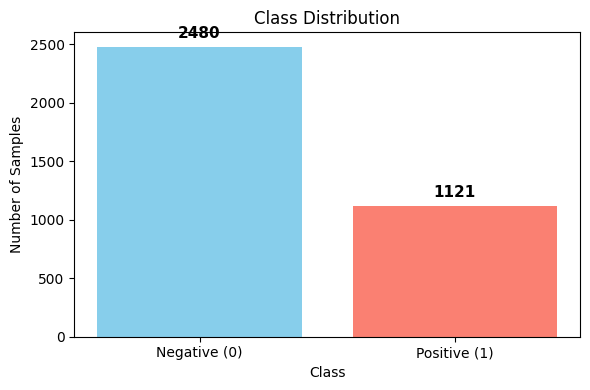

In [ ]:
# Combine the datasets
data = pd.concat([neg_data, pos_data], axis=0).reset_index(drop=True)
X = data.drop(columns=['Target'])
y = data['Target']

# Plot class distribution
import matplotlib.pyplot as plt

class_counts = y.value_counts().sort_index()
plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index, class_counts.values, color=['skyblue', 'salmon'])
plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'], rotation=0)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

# Add the counts on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50, str(int(height)),
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
data.to_csv('balanced_Data.csv', index=False)

In [ ]:
data.isna().sum().sum()

np.int64(0)

In [ ]:
data['Target'].value_counts()

,count
Target,
0,2480
1,1121


# **Displaying dataset after applying smote**

<ipython-input-12-fee9857452ba>:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  balanced_data['Target'] = y_resampled


Target
0    2480
1    2480
Name: count, dtype: int64


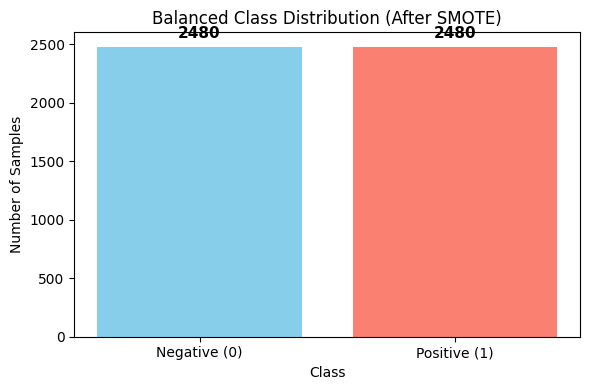

In [ ]:
X = data.drop(columns=['Target'])
y = data['Target']

# Apply SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Create balanced DataFrame
balanced_data = pd.DataFrame(X_resampled, columns=X.columns)
balanced_data['Target'] = y_resampled

# Save the balanced dataset as CSV
balanced_data.to_csv('balanced_data.csv', index=False)

# Check class distribution
print(balanced_data['Target'].value_counts())  # Should be balanced

# Plot class distribution after SMOTE
class_counts_bal = balanced_data['Target'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts_bal.index, class_counts_bal.values, color=['skyblue', 'salmon'])
plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'], rotation=0)
plt.title('Balanced Class Distribution (After SMOTE)')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

# Add the counts on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50, str(int(height)),
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
balanced_data.to_csv('balanced_data_AFTER_SMOTE.csv')

In [ ]:
df = pd.read_csv('balanced_data.csv')
df.head()

,as_1,as_2,as_3,as_4,as_5,as_6,as_7,as_8,as_9,as_10,...,as_791,as_792,as_793,as_794,as_795,as_796,as_797,as_798,as_799,Target
0,497,1749,0,320,0,0,0,0,307,0,...,0,0,0,0,0,0,0,0,0,0
1,407,106,46,19,0,0,0,0,0,2030,...,0,0,0,0,0,0,0,0,0,0
2,107,41,0,37,95,0,0,61,0,80,...,0,0,0,3,0,0,0,0,0,0
3,0,1202,421,582,90,0,0,0,348,0,...,0,0,0,0,0,0,0,0,0,0
4,41,0,0,0,0,6100,169,0,31,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape}, Testing set size: {X_test.shape}")


Training set size: (3968, 799), Testing set size: (992, 799)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Random forest non tuned**

In [ ]:
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# AUC Score (for binary classification)
auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
auc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

# Sensitivity (Recall for the positive class)
conf_matrix = confusion_matrix(y_test, y_test_pred)
TP = conf_matrix[1, 1]  # True Positives
FN = conf_matrix[1, 0]  # False Negatives
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0

# Print results
print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Train AUC Score:", auc_train)
print("Test AUC Score:", auc_test)
print("Sensitivity (Recall):", sensitivity)
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Training Accuracy: 0.8331653225806451
Test Accuracy: 0.7479838709677419
Train AUC Score: 0.915030805923192
Test AUC Score: 0.8170891324141519
Sensitivity (Recall): 0.6794354838709677
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.82      0.76       496
           1       0.79      0.68      0.73       496

    accuracy                           0.75       992
   macro avg       0.75      0.75      0.75       992
weighted avg       0.75      0.75      0.75       992



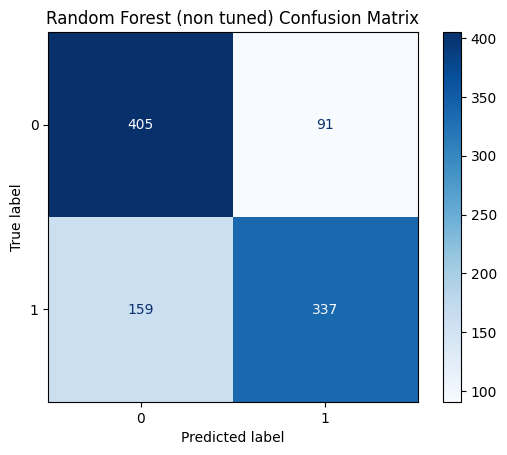

In [ ]:
#new
# Confusion Matrix Visualization
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title("Random Forest (non tuned) Confusion Matrix")
plt.show()

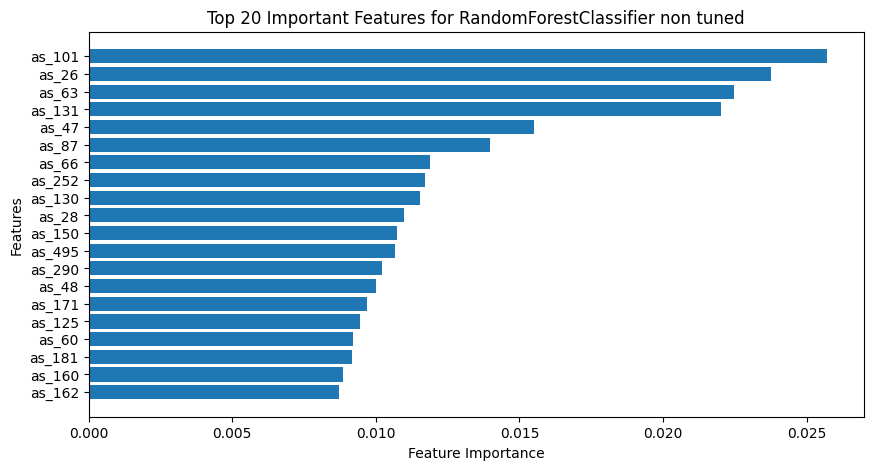

In [ ]:
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 5))
plt.barh(X.columns[sorted_idx[:20]], feature_importance[sorted_idx[:20]])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 20 Important Features for RandomForestClassifier non tuned")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# new
feature_importance_df = pd.DataFrame({
    "Feature": X.columns[sorted_idx],
    "Importance": feature_importance[sorted_idx]
})

# Save to CSV
feature_importance_df.to_csv("NonTuned_RF_feature_importance.csv", index=False)

print("Feature importance saved to 'feature_importance.csv'")

Feature importance saved to 'feature_importance.csv'


# **XGBOOST NON TUNED**

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Accuracy
train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)

# AUC
auc_train_xgb = roc_auc_score(y_train, xgb_model.predict_proba(X_train)[:, 1])
auc_test_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

# Sensitivity (Recall for the positive class)
conf_matrix_xgb = confusion_matrix(y_test, y_test_pred_xgb)
TP = conf_matrix_xgb[1, 1]
FN = conf_matrix_xgb[1, 0]
sensitivity_xgb = TP / (TP + FN) if (TP + FN) > 0 else 0

print("XGBoost (Non-Tuned) Results:")
print("Training Accuracy:", train_acc_xgb)
print("Test Accuracy:", test_acc_xgb)
print("Train AUC Score:", auc_train_xgb)
print("Test AUC Score:", auc_test_xgb)
print("Sensitivity (Recall):", sensitivity_xgb)
print("Classification Report:\n", classification_report(y_test, y_test_pred_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:48:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost (Non-Tuned) Results:
Training Accuracy: 0.9994959677419355
Test Accuracy: 0.7832661290322581
Train AUC Score: 0.9999992378544486
Test AUC Score: 0.864317767950052
Sensitivity (Recall): 0.7338709677419355
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.83      0.79       496
           1       0.81      0.73      0.77       496

    accuracy                           0.78       992
   macro avg       0.79      0.78      0.78       992
weighted avg       0.79      0.78      0.78       992



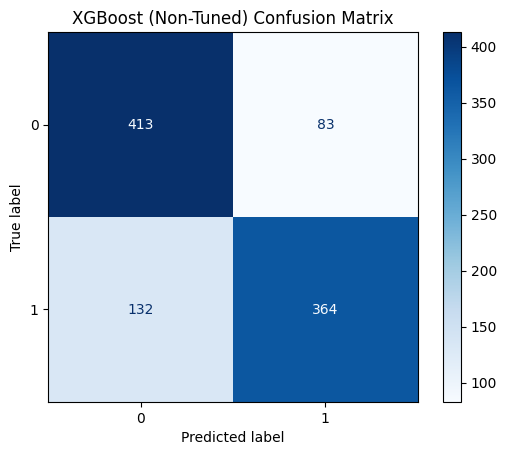

In [ ]:
# Confusion Matrix
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_xgb)
disp_xgb.plot(cmap='Blues')
plt.title("XGBoost (Non-Tuned) Confusion Matrix")
plt.show()


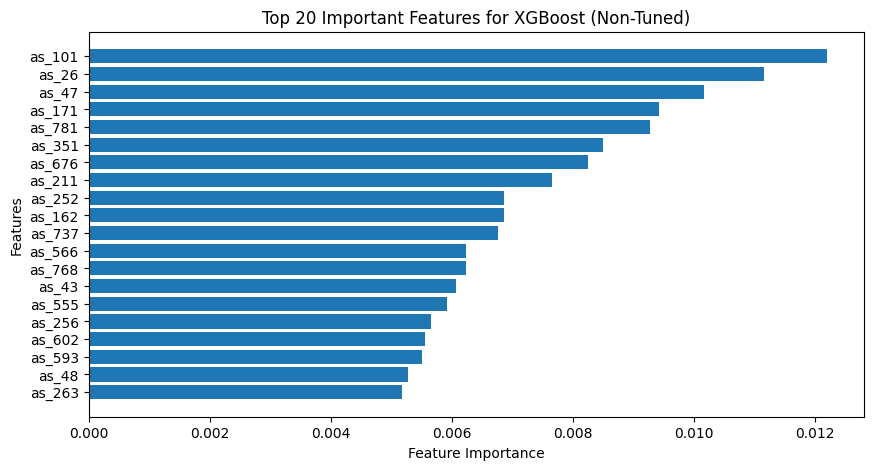

In [ ]:
xgb_importance = xgb_model.feature_importances_
xgb_sorted_idx = np.argsort(xgb_importance)[::-1]

plt.figure(figsize=(10, 5))
plt.barh(X.columns[xgb_sorted_idx[:20]], xgb_importance[xgb_sorted_idx[:20]])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 20 Important Features for XGBoost (Non-Tuned)")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
xgb_feature_importance_df = pd.DataFrame({
    "Feature": X.columns[xgb_sorted_idx],
    "Importance": xgb_importance[xgb_sorted_idx]
})

xgb_feature_importance_df.to_csv("NonTuned_XGB_feature_importance.csv", index=False)
print("XGBoost feature importance saved to 'NonTuned_XGB_feature_importance.csv'")


XGBoost feature importance saved to 'NonTuned_XGB_feature_importance.csv'


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# ----------------------- Random Forest Setup -----------------------
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [20, 40],
    'min_samples_leaf': [10, 15],
    'bootstrap': [True],
    'max_features': ['sqrt']
}

rf_model = RandomForestClassifier(
    random_state=42,
    max_samples=0.75,
    oob_score=True,
    class_weight='balanced'
)

rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='roc_auc',
    error_score='raise'
)

rf_grid_search.fit(X_train, y_train)
print("Random Forest - Best Parameters:", rf_grid_search.best_params_)
best_rf_model = rf_grid_search.best_estimator_

# ----------------------- XGBoost Setup -----------------------
xgb_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1]
}

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=1
)

xgb_grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='roc_auc',
    error_score='raise'
)

xgb_grid_search.fit(X_train, y_train)
print("XGBoost - Best Parameters:", xgb_grid_search.best_params_)
best_xgb_model = xgb_grid_search.best_estimator_


Fitting 10 folds for each of 1250 candidates, totalling 12500 fits
Random Forest - Best Parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 100}
Fitting 10 folds for each of 729 candidates, totalling 7290 fits


# **Random forest after tuning**

In [ ]:
# Get the best model from Grid Search
best_rf = grid_search.best_estimator_
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# AUC Score (for binary classification)
auc_train = roc_auc_score(y_train, best_rf.predict_proba(X_train)[:, 1])
auc_test = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

# Sensitivity (Recall for the positive class)
conf_matrix = confusion_matrix(y_test, y_test_pred)
TP = conf_matrix[1, 1]  # True Positives
FN = conf_matrix[1, 0]  # False Negatives
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0

# Print results
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Train AUC Score: {auc_train:.4f}")
print(f"Test AUC Score: {auc_test:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_test_pred))


Training Accuracy: 0.9496
Test Accuracy: 0.7823
Train AUC Score: 0.9929
Test AUC Score: 0.8563
Sensitivity (Recall): 0.7137
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       496
           1       0.83      0.71      0.77       496

    accuracy                           0.78       992
   macro avg       0.79      0.78      0.78       992
weighted avg       0.79      0.78      0.78       992



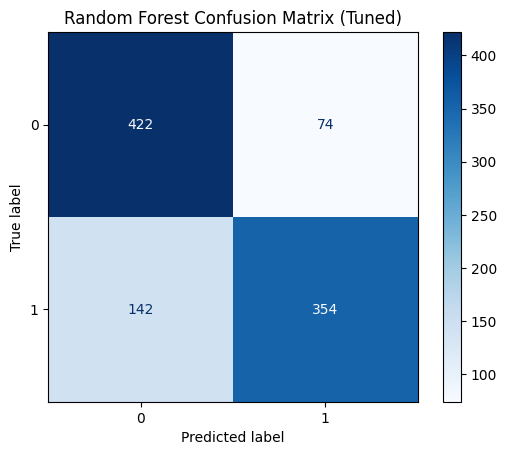

In [ ]:
# new
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix (Tuned)")
plt.show()


Top 20 Important Features:
         Feature  Importance
62    Feature 62    0.012883
130  Feature 130    0.012093
25    Feature 25    0.011772
100  Feature 100    0.010011
3      Feature 3    0.008666
149  Feature 149    0.008078
63    Feature 63    0.007953
49    Feature 49    0.007547
21    Feature 21    0.007479
29    Feature 29    0.007470
52    Feature 52    0.007427
129  Feature 129    0.007361
59    Feature 59    0.006985
172  Feature 172    0.006960
86    Feature 86    0.006709
494  Feature 494    0.006619
124  Feature 124    0.006461
2      Feature 2    0.006408
27    Feature 27    0.006302
68    Feature 68    0.006266


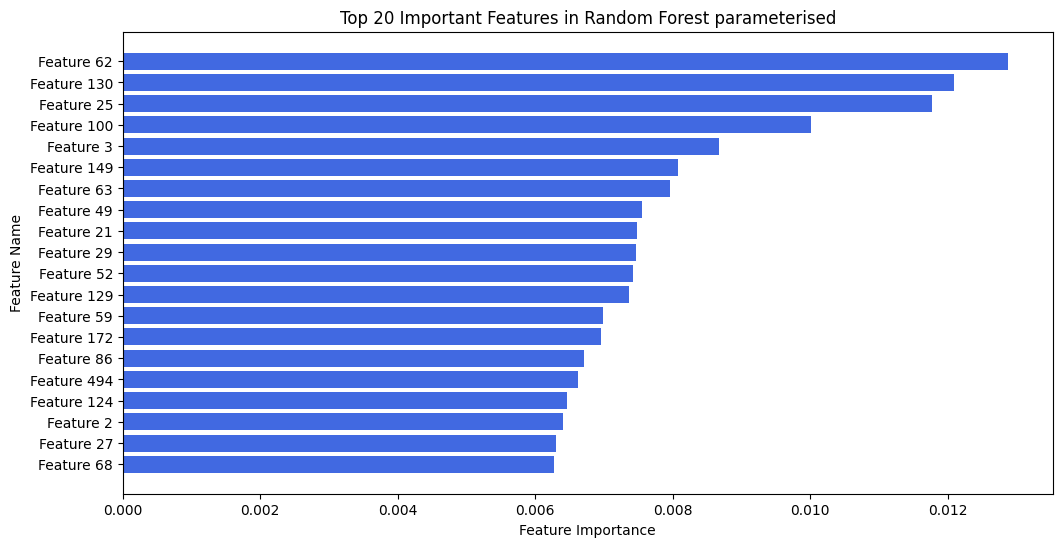

In [ ]:
feature_importances = best_rf.feature_importances_

# Create a DataFrame for easy sorting
feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else [f"Feature {i}" for i in range(len(feature_importances))]
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort by importance
top_features = feature_importance_df.sort_values(by="Importance", ascending=False).head(20)

# Print top 20 features
print("\nTop 20 Important Features:")
print(top_features)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(top_features["Feature"], top_features["Importance"], color="royalblue")
plt.gca().invert_yaxis()  # Invert y-axis to show the most important at the top
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("Top 20 Important Features in Random Forest parameterised")
plt.show()

In [ ]:
# Save all features in descending order to CSV
all_features_sorted = feature_importance_df.sort_values(by="Importance", ascending=False)
all_features_sorted.to_csv("feature_importance_RF_tuned.csv", index=False)

print("Feature importance saved to 'feature_importance_tuned.csv'")


Feature importance saved to 'feature_importance_tuned.csv'


# **XGBOOST AFTER TUNING**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# Get the best model from Grid Search
best_xgb = grid_search.best_estimator_

# Make predictions
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# Handle multi-class AUC properly
if len(set(y_train)) > 2:  # Check if it's multi-class
    auc_train = roc_auc_score(y_train, best_xgb.predict_proba(X_train), multi_class="ovr")
    auc_test = roc_auc_score(y_test, best_xgb.predict_proba(X_test), multi_class="ovr")
else:  # Binary classification
    auc_train = roc_auc_score(y_train, best_xgb.predict_proba(X_train)[:, 1])
    auc_test = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])

# Confusion  Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Sensitivity (Recall) Calculation (for Binary Classification)
if conf_matrix.shape == (2, 2):  # Ensure it's binary classification
    TP = conf_matrix[1, 1]  # True Positives
    FN = conf_matrix[1, 0]  # False Negatives
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
else:
    sensitivity = None  # Not applicable for multi-class

# Print results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Train AUC Score: {auc_train:.4f}")
print(f"Test AUC Score: {auc_test:.4f}")

if sensitivity is not None:
    print(f"Sensitivity (Recall): {sensitivity:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_test_pred))


Best Parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.8538127839483101
Training Accuracy: 0.9496
Test Accuracy: 0.7823
Train AUC Score: 0.9929
Test AUC Score: 0.8563
Sensitivity (Recall): 0.7137
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       496
           1       0.83      0.71      0.77       496

    accuracy                           0.78       992
   macro avg       0.79      0.78      0.78       992
weighted avg       0.79      0.78      0.78       992



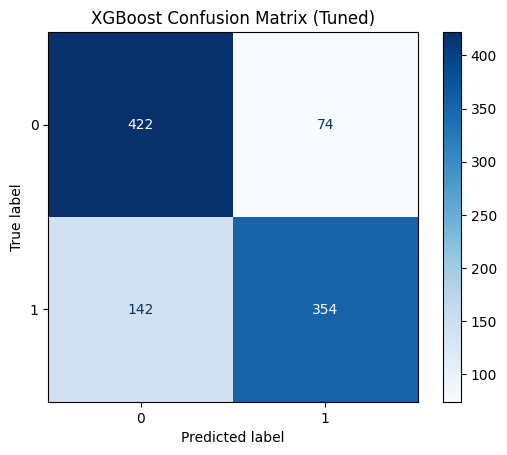

In [ ]:
# new
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title("XGBoost Confusion Matrix (Tuned)")
plt.show()

In [ ]:
# Get feature importances from the best XGBoost model
feature_importances = best_xgb.feature_importances_

# Create a DataFrame for easy sorting
feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else [f"Feature {i}" for i in range(len(feature_importances))]
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort and select top 20 features
top_features = feature_importance_df.sort_values(by="Importance", ascending=False).head(20)

# Print top 20 features
print("\nTop 20 Important Features (XGBoost Tuned):")
print(top_features)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(top_features["Feature"], top_features["Importance"], color="darkorange")
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("Top 20 Important Features in XGBoost (Tuned)")
plt.tight_layout()
plt.show()


In [ ]:
# Save all features (sorted by importance) to CSV
all_features_sorted = feature_importance_df.sort_values(by="Importance", ascending=False)
all_features_sorted.to_csv("feature_importance_XGB_tuned.csv", index=False)

print("Feature importance saved to 'feature_importance_XGB_tuned.csv'")


## Ensemble

Training Accuracy: 0.9700
Test Accuracy: 0.9050

# **ENSEMBLE**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# Create dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature names
feature_names = [f"Feature {i}" for i in range(X.shape[1])]
X_train_df = pd.DataFrame(X_train, columns=feature_names)

# Optimized RandomForest model
best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=10,
    min_samples_split=30,
    bootstrap=True,
    random_state=42
)

# Optimized XGBoost model
best_xgb = XGBClassifier(
    n_estimators=90,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric='logloss'
)

# Voting Classifier
voting_clf = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    voting='soft'
)

# Train ensemble
voting_clf.fit(X_train, y_train)

# Predictions
y_train_pred = voting_clf.predict(X_train)
y_test_pred = voting_clf.predict(X_test)

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
auc_train = roc_auc_score(y_train, voting_clf.predict_proba(X_train)[:, 1])
auc_test = roc_auc_score(y_test, voting_clf.predict_proba(X_test)[:, 1])
conf_matrix = confusion_matrix(y_test, y_test_pred)
TP = conf_matrix[1, 1]
FN = conf_matrix[1, 0]
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0

# === Feature Importance === #
# Extract feature importances
rf_feature_importance = best_rf.fit(X_train, y_train).feature_importances_
xgb_feature_importance = best_xgb.fit(X_train, y_train).feature_importances_

# Combine into DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RF Importance': rf_feature_importance,
    'XGB Importance': xgb_feature_importance
})

# Average importance (for secondary output)
importance_df['Average Importance'] = (importance_df['RF Importance'] + importance_df['XGB Importance']) / 2

# Rank features (lower = better)
importance_df['RF Rank'] = importance_df['RF Importance'].rank(ascending=False, method='min')
importance_df['XGB Rank'] = importance_df['XGB Importance'].rank(ascending=False, method='min')

# Borda Count (sum of ranks)
importance_df['Borda Score'] = importance_df['RF Rank'] + importance_df['XGB Rank']

# Top 20 by Rank Aggregation
top_20_features = importance_df.sort_values(by='Borda Score').head(20)

# Features with average importance > 0
non_zero_avg = importance_df[importance_df['Average Importance'] > 0].sort_values(by='Average Importance', ascending=False)

# === Output === #
print("=== Model Performance ===")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Train AUC Score: {auc_train:.4f}")
print(f"Test AUC Score: {auc_test:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")

print("\n=== Top 20 Features Based on Rank Aggregation (Borda Count) ===")
print(top_20_features[['Feature', 'RF Importance', 'XGB Importance', 'Borda Score']])

print("\n=== Features with Average Importance > 0 (Initial Method) ===")
print(non_zero_avg[['Feature', 'Average Importance']])

print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred))


=== Model Performance ===
Training Accuracy: 0.9700
Test Accuracy: 0.9050
Train AUC Score: 0.9981
Test AUC Score: 0.9383
Sensitivity (Recall): 0.8598

=== Top 20 Features Based on Rank Aggregation (Borda Count) ===
       Feature  RF Importance  XGB Importance  Borda Score
5    Feature 5       0.436348        0.411659          2.0
18  Feature 18       0.258302        0.054562          5.0
14  Feature 14       0.073417        0.086574          6.0
1    Feature 1       0.116508        0.041496          7.0
11  Feature 11       0.017113        0.032933         10.0
13  Feature 13       0.008401        0.028493         14.0
6    Feature 6       0.007962        0.027265         17.0
10  Feature 10       0.008632        0.023978         20.0
16  Feature 16       0.007938        0.026582         20.0
2    Feature 2       0.007812        0.026639         20.0
15  Feature 15       0.005033        0.028619         23.0
0    Feature 0       0.008148        0.022874         24.0
3    Feature 3    

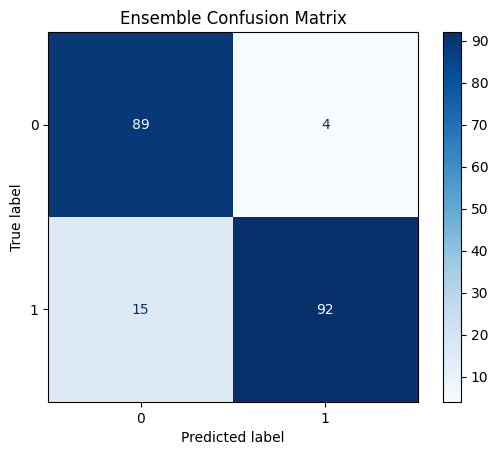

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title("Ensemble Confusion Matrix")
plt.show()

# Save feature importances to CSV
feature_importance_df.to_csv("feature_importance_for_ensemble.csv", index=False)

In [ ]:
import joblib

# Save the trained voting classifier
joblib.dump(voting_clf, "voting_classifier_ensemble.pkl")
print("Model saved successfully.")


Model saved successfully.


In [ ]:
feature_importance_df

,Feature,Importance
0,Feature 0,0.005813
1,Feature 1,0.004774
2,Feature 2,0.006408
3,Feature 3,0.008666
4,Feature 4,0.004556
...,...,...
794,Feature 794,0.000369
795,Feature 795,0.000087
796,Feature 796,0.000278
797,Feature 797,0.000000


In [ ]:
# # Extract feature importances from trained models
# rf_importances = best_rf.feature_importances_
# xgb_importances = best_xgb.feature_importances_

# importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'RF Importance': rf_importances,
#     'XGB Importance': xgb_importances,
# })

# # Ranking
# importance_df['RF Rank'] = importance_df['RF Importance'].rank(ascending=False)
# importance_df['XGB Rank'] = importance_df['XGB Importance'].rank(ascending=False)

# # Borda Count
# importance_df['Borda Score'] = importance_df['RF Rank'] + importance_df['XGB Rank']



<ipython-input-37-fd86ecb5a011>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


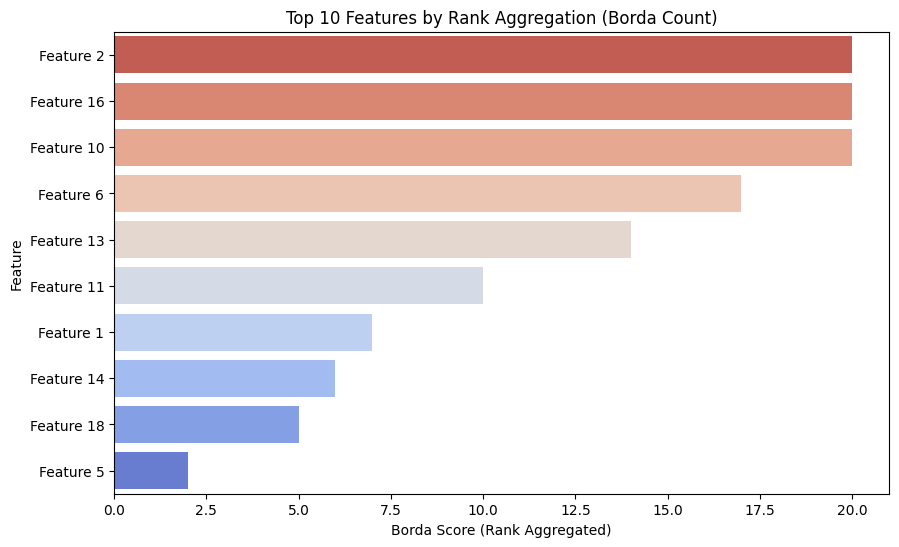

In [ ]:
# 🔎 Sort features by Borda Score
importance_df_sorted = importance_df.sort_values(by='Borda Score', ascending=True).head(10)

# 📊 Plot Top 10 Features by Borda Score
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(
    y=importance_df_sorted['Feature'],
    x=importance_df_sorted['Borda Score'],
    palette='coolwarm'
)

plt.xlabel("Borda Score (Rank Aggregated)")
plt.ylabel("Feature")
plt.title("Top 10 Features by Rank Aggregation (Borda Count)")
plt.gca().invert_yaxis()  # Puts the most important feature at the top
plt.show()


# with only top features

In [ ]:
# Feature Importance Extraction
rf_feature_importance = best_rf.fit(X_train, y_train).feature_importances_
xgb_feature_importance = best_xgb.fit(X_train, y_train).feature_importances_

# Store in DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RandomForest Importance': rf_feature_importance,
    'XGBoost Importance': xgb_feature_importance
})


In [ ]:
# Add rank columns
feature_importance_df["RF Rank"] = feature_importance_df["RandomForest Importance"].rank(ascending=False)
feature_importance_df["XGB Rank"] = feature_importance_df["XGBoost Importance"].rank(ascending=False)

# Average or Borda-style rank aggregation
feature_importance_df["Rank"] = (feature_importance_df["RF Rank"] + feature_importance_df["XGB Rank"]) / 2



=== Model Performance with Top Features (Rank Aggregation) ===
Training Accuracy: 0.9637
Test Accuracy: 0.8950
Train AUC Score: 0.9969
Test AUC Score: 0.9396
Sensitivity (Recall): 0.8411


<ipython-input-40-d27e7e40d43a>:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


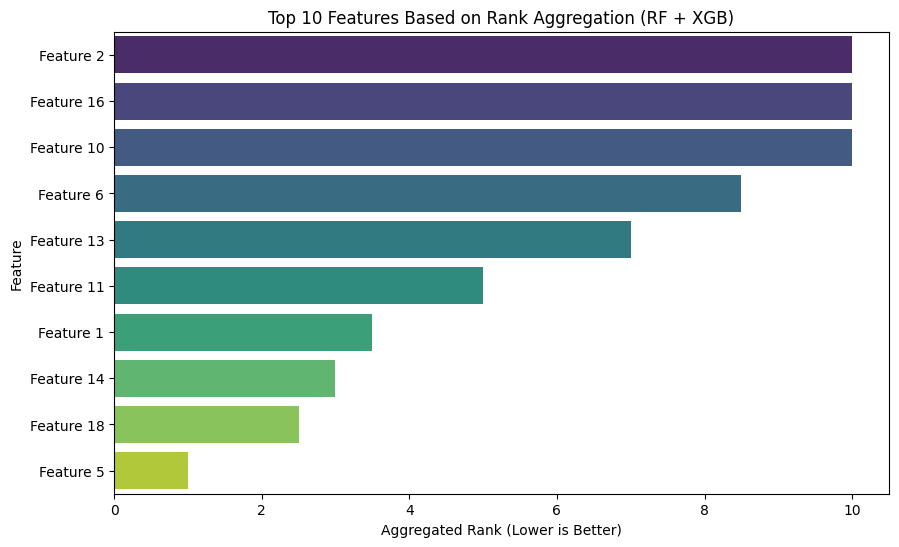

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top N features using aggregated rank from feature_importance_df
top_n = 10
top_features = feature_importance_df.sort_values(by="Rank").head(top_n)["Feature"].tolist()

# Use only the selected features for training
X_train_selected = X_train_df[top_features]
X_test_selected = pd.DataFrame(X_test, columns=feature_names)[top_features]

# Train the Voting Classifier again with top features
voting_clf.fit(X_train_selected, y_train)

# Predictions using reduced feature set
y_train_pred_selected = voting_clf.predict(X_train_selected)
y_test_pred_selected = voting_clf.predict(X_test_selected)

# Accuracy
train_acc_selected = accuracy_score(y_train, y_train_pred_selected)
test_acc_selected = accuracy_score(y_test, y_test_pred_selected)

# AUC Score
auc_train_selected = roc_auc_score(y_train, voting_clf.predict_proba(X_train_selected)[:, 1])
auc_test_selected = roc_auc_score(y_test, voting_clf.predict_proba(X_test_selected)[:, 1])

# Sensitivity (Recall for positive class)
conf_matrix_selected = confusion_matrix(y_test, y_test_pred_selected)
TP = conf_matrix_selected[1, 1]
FN = conf_matrix_selected[1, 0]
sensitivity_selected = TP / (TP + FN) if (TP + FN) > 0 else 0

# Print Results
print("\n=== Model Performance with Top Features (Rank Aggregation) ===")
print(f"Training Accuracy: {train_acc_selected:.4f}")
print(f"Test Accuracy: {test_acc_selected:.4f}")
print(f"Train AUC Score: {auc_train_selected:.4f}")
print(f"Test AUC Score: {auc_test_selected:.4f}")
print(f"Sensitivity (Recall): {sensitivity_selected:.4f}")

# Plot Top N Feature Ranks (not importance scores since we used rank-based method)
plt.figure(figsize=(10, 6))
sns.barplot(
    y=feature_importance_df.sort_values(by="Rank")["Feature"][:top_n],
    x=feature_importance_df.sort_values(by="Rank")["Rank"][:top_n],
    palette="viridis_r"
)
plt.xlabel("Aggregated Rank (Lower is Better)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Features Based on Rank Aggregation (RF + XGB)")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# permutation

In [ ]:
import joblib
joblib.dump(voting_clf, "voting_classifier_rank_based.pkl")
print("✅ Rank-based top feature model saved!")


✅ Rank-based top feature model saved!


# permutation

**Load Model**

In [ ]:
import joblib

# Load the rank-based model
modelPerm = joblib.load("voting_classifier_rank_based.pkl")
print("✅ Rank-based model loaded successfully!")


✅ Rank-based model loaded successfully!


**Compute Permutation Importance on Top Features**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

# Use only the top N features
top_features = feature_importance_df.sort_values(by="Rank").head(10)["Feature"].tolist()
X_test_selected = pd.DataFrame(X_test, columns=feature_names)[top_features]

# Compute permutation importance on selected features
result = permutation_importance(
    modelPerm, X_test_selected, y_test, n_repeats=15, random_state=42, n_jobs=-1
)

# Store results
importance_df = pd.DataFrame({
    "Feature": X_test_selected.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print("📊 Top 10 Features by Permutation Importance:")
print(importance_df.head(10))


📊 Top 10 Features by Permutation Importance:
      Feature  Importance
0   Feature 5    0.357667
2  Feature 14    0.059667
4  Feature 11    0.006333
6   Feature 6   -0.003667
3   Feature 1   -0.004000
8  Feature 16   -0.005333
7  Feature 10   -0.006667
5  Feature 13   -0.008667
9   Feature 2   -0.008667
1  Feature 18   -0.009000


**Save to CSV**

In [ ]:
# Save importance scores to CSV
importance_df.to_csv("permutation_importance_rank_based.csv", index=False)



**Display DataFrame**

In [ ]:
# Display the full importance table
importance_df


,Feature,Importance
0,Feature 5,0.357667
2,Feature 14,0.059667
4,Feature 11,0.006333
6,Feature 6,-0.003667
3,Feature 1,-0.004000
8,Feature 16,-0.005333
7,Feature 10,-0.006667
5,Feature 13,-0.008667
9,Feature 2,-0.008667
1,Feature 18,-0.009000


**Plot Permutation Importance**

<ipython-input-46-516f2ee58a89>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


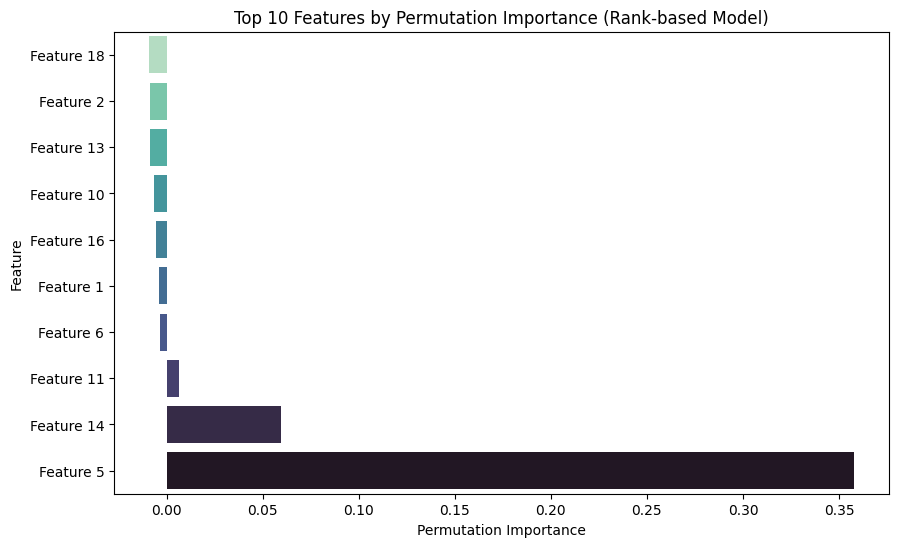

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(
    y=importance_df["Feature"],
    x=importance_df["Importance"],
    palette="mako"
)
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features by Permutation Importance (Rank-based Model)")
plt.gca().invert_yaxis()
plt.show()


rough leave

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.ensemble import RandomForestClassifier, VotingClassifier
# from xgboost import XGBClassifier
# from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# from sklearn.metrics import (
#     accuracy_score, roc_auc_score, classification_report, confusion_matrix
# )
# from scipy.stats import spearmanr
# from sklearn.preprocessing import StandardScaler

# # Load dataset
# data = pd.read_csv("/content/balanced_data.csv")
# X = data.drop(columns=['Target'])  # Assuming 'Target' is the label
# y = data['Target']

# # Compute Spearman correlation with target
# correlations = {col: spearmanr(X[col], y).correlation for col in X.columns}
# correlation_df = pd.DataFrame(correlations.items(), columns=['Feature', 'Correlation'])
# correlation_df = correlation_df.sort_values(by='Correlation', ascending=False)

# # Select top 30 features
# top_features = correlation_df.head(30)['Feature'].tolist()
# X_selected = X[top_features]

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

# # Scale data
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Random Forest Model
# rf = RandomForestClassifier(
#     n_estimators=50,
#     max_depth=5,
#     min_samples_leaf=5,
#     random_state=42,
#     class_weight='balanced'
# )
# rf.fit(X_train_scaled, y_train)

# # XGBoost Model
# xgb = XGBClassifier(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.05,
#     reg_lambda=1,
#     reg_alpha=1,
#     eval_metric="auc",
#     random_state=42
# )
# xgb.fit(X_train_scaled, y_train)

# # Ensemble Model
# ensemble = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb)], voting='soft')
# ensemble.fit(X_train_scaled, y_train)

# # Function to calculate all metrics
# def evaluate_model(model, X_train, y_train, X_test, y_test, name):
#     y_train_pred = model.predict(X_train)
#     y_test_pred = model.predict(X_test)

#     y_train_prob = model.predict_proba(X_train)[:, 1]
#     y_test_prob = model.predict_proba(X_test)[:, 1]

#     # AUC
#     train_auc = roc_auc_score(y_train, y_train_prob)
#     test_auc = roc_auc_score(y_test, y_test_prob)

#     # Accuracy
#     train_acc = accuracy_score(y_train, y_train_pred)
#     test_acc = accuracy_score(y_test, y_test_pred)

#     # Confusion Matrix
#     tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, y_train_pred).ravel()
#     tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, y_test_pred).ravel()

#     # Sensitivity (Recall for class 1)
#     train_sensitivity = tp_train / (tp_train + fn_train)
#     test_sensitivity = tp_test / (tp_test + fn_test)

#     # Specificity (Recall for class 0)
#     train_specificity = tn_train / (tn_train + fp_train)
#     test_specificity = tn_test / (tn_test + fp_test)

#     # Precision, Recall, F1-score
#     report_test = classification_report(y_test, y_test_pred, output_dict=True)
#     report_train = classification_report(y_train, y_train_pred, output_dict=True)

#     print(f"🔹 {name} Model Metrics")
#     print(f"Train - AUC: {train_auc:.4f}, Accuracy: {train_acc:.4f}, Sensitivity: {train_sensitivity:.4f}, Specificity: {train_specificity:.4f}")
#     print(f"Test  - AUC: {test_auc:.4f}, Accuracy: {test_acc:.4f}, Sensitivity: {test_sensitivity:.4f}, Specificity: {test_specificity:.4f}")
#     print(f"Train Precision: {report_train['1']['precision']:.4f}, Recall: {report_train['1']['recall']:.4f}, F1-score: {report_train['1']['f1-score']:.4f}")
#     print(f"Test  Precision: {report_test['1']['precision']:.4f}, Recall: {report_test['1']['recall']:.4f}, F1-score: {report_test['1']['f1-score']:.4f}")
#     print("-" * 80)

# # Evaluate all models
# evaluate_model(rf, X_train_scaled, y_train, X_test_scaled, y_test, "Random Forest")
# evaluate_model(xgb, X_train_scaled, y_train, X_test_scaled, y_test, "XGBoost")
# evaluate_model(ensemble, X_train_scaled, y_train, X_test_scaled, y_test, "Ensemble")


🔹 Random Forest Model Metrics
Train - AUC: 0.7940, Accuracy: 0.7228, Sensitivity: 0.6477, Specificity: 0.7979
Test  - AUC: 0.7609, Accuracy: 0.6895, Sensitivity: 0.6089, Specificity: 0.7702
Train Precision: 0.7622, Recall: 0.6477, F1-score: 0.7003
Test  Precision: 0.7260, Recall: 0.6089, F1-score: 0.6623
--------------------------------------------------------------------------------
🔹 XGBoost Model Metrics
Train - AUC: 0.8847, Accuracy: 0.8226, Sensitivity: 0.7424, Specificity: 0.9027
Test  - AUC: 0.7862, Accuracy: 0.7198, Sensitivity: 0.6613, Specificity: 0.7782
Train Precision: 0.8842, Recall: 0.7424, F1-score: 0.8071
Test  Precision: 0.7489, Recall: 0.6613, F1-score: 0.7024
--------------------------------------------------------------------------------
🔹 Ensemble Model Metrics
Train - AUC: 0.8650, Accuracy: 0.8019, Sensitivity: 0.7177, Specificity: 0.8861
Test  - AUC: 0.7843, Accuracy: 0.7177, Sensitivity: 0.6573, Specificity: 0.7782
Train Precision: 0.8630, Recall: 0.7177, F1-sco

In [ ]:
top_features

['Feature 5',
 'Feature 18',
 'Feature 14',
 'Feature 1',
 'Feature 11',
 'Feature 13',
 'Feature 6',
 'Feature 16',
 'Feature 2',
 'Feature 15']